<hr style="border: 4px solid #2e7d32;">

**<h1 style="font-size:36px;">📊 Big Data dan Machine Learning dengan PySpark</h1>**

Tugas ini bertujuan untuk melakukan analisis dan membangun model Machine Learning berbasis data besar dengan menggunakan PySpark pada dataset New York City Taxi Fare Prediction yang diambil dari Kaggle:

🔗 [New York City Taxi Fare Prediction](https://www.kaggle.com/competitions/new-york-city-taxi-fare-prediction/)

<hr style="border: 4px solid #2e7d32;">

<div style="width: 100%; overflow: hidden;">
  <!-- Tabel Anila di kiri -->
  <div style="width: 45%; float: left;">
    <table style="font-size:18px; border-collapse: collapse; width: 100%;">
      <tr>
        <td colspan="2" style="font-weight:bold; font-size:22px; background-color:#f2f2f2; padding:8px;">
          👩🏻‍💻 Identitas Mahasiswa - Anggota 1
        </td>
      </tr>
      <tr>
        <td style="font-weight:bold; width: 150px; padding:6px;">Nama</td>
        <td style="padding:6px;">: Anila Dwi Lestari</td>
      </tr>
      <tr>
        <td style="font-weight:bold; padding:6px;">Kelas</td>
        <td style="padding:6px;">: IF-46-DSIS.01</td>
      </tr>
      <tr>
        <td style="font-weight:bold; padding:6px;">NIM</td>
        <td style="padding:6px;">: 1301223153</td>
      </tr>
    </table>
  </div>

  <!-- Tabel Rangga di kanan -->
  <div style="width: 45%; float: right;">
    <table style="font-size:18px; border-collapse: collapse; width: 100%;">
      <tr>
        <td colspan="2" style="font-weight:bold; font-size:22px; background-color:#f2f2f2; padding:8px;">
          🧑🏻‍💻 Identitas Mahasiswa - Anggota 2
        </td>
      </tr>
      <tr>
        <td style="font-weight:bold; width:150px; padding:6px;">Nama</td>
        <td style="padding:6px;">: I Dewa Putu Rangga Putra Dharma</td>
      </tr>
      <tr>
        <td style="font-weight:bold; padding:6px;">Kelas</td>
        <td style="padding:6px;">: IF-46-DSIS.01</td>
      </tr>
      <tr>
        <td style="font-weight:bold; padding:6px;">NIM</td>
        <td style="padding:6px;">: 1301220427</td>
      </tr>
    </table>
  </div>
</div>

# 1. Installing PySpark in Google Colab

In [ ]:
!sudo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
#Check this site for the latest download link https://www.apache.org/dyn/closer.lua/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!wget -q https://dlcdn.apache.org/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!tar xf spark-3.2.1-bin-hadoop3.2.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j

import os
import sys
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
# os.environ["SPARK_HOME"] = "/content/spark-3.2.1-bin-hadoop3.2"


import findspark
findspark.init()
findspark.find()

import pyspark

from pyspark.sql import DataFrame, SparkSession
from typing import List
import pyspark.sql.types as T
import pyspark.sql.functions as F

spark= SparkSession \
       .builder \
       .appName("Our First Spark Example") \
       .getOrCreate()

spark

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,123 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,42

# 2. Reading Data

In [ ]:
from google.colab import files
files.upload()  # pilih file kaggle.json dari komputer kamu

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"puturangga25","key":"4b16bf9a72eb5a7c6c60f71bfee6a3b8"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c new-york-city-taxi-fare-prediction

 98% 1.53G/1.56G [00:08<00:00, 121MB/s] 
100% 1.56G/1.56G [00:08<00:00, 188MB/s]


In [ ]:
!unzip -o new-york-city-taxi-fare-prediction.zip -d nyc_taxi

Archive:  new-york-city-taxi-fare-prediction.zip
  inflating: nyc_taxi/GCP-Coupons-Instructions.rtf  
  inflating: nyc_taxi/sample_submission.csv  
  inflating: nyc_taxi/test.csv       
  inflating: nyc_taxi/train.csv      


In [ ]:
!ls nyc_taxi

GCP-Coupons-Instructions.rtf  sample_submission.csv  test.csv  train.csv


#3. PySpark DataFrames

In [ ]:
df = spark.read.csv('/content/nyc_taxi/train.csv', header=True, inferSchema=True)
df.printSchema()

root
 |-- key: timestamp (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- passenger_count: integer (nullable = true)



In [ ]:
print("\n============================== INFORMASI DATASET ==============================")

# Jumlah baris dan kolom
num_rows = df.count()
num_cols = len(df.columns)

print(f"Ukuran Data (baris, kolom): ({num_rows:,}, {num_cols})")
print(f"Jumlah baris dataset: {num_rows:,}")
print(f"Jumlah kolom dataset: {num_cols}")


============================== INFORMASI DATASET ==============================
Ukuran Data (baris, kolom): (55,423,856, 8)
Jumlah baris dataset: 55,423,856
Jumlah kolom dataset: 8


In [ ]:
# Menampilkan tipe data setiap kolom
print("\nTipe Data Setiap Kolom:")
for field in df.schema.fields:
    print(f"- {field.name}: {field.dataType}")


Tipe Data Setiap Kolom:
- key: TimestampType()
- fare_amount: DoubleType()
- pickup_datetime: TimestampType()
- pickup_longitude: DoubleType()
- pickup_latitude: DoubleType()
- dropoff_longitude: DoubleType()
- dropoff_latitude: DoubleType()
- passenger_count: IntegerType()


## 📘 Penjelasan Kolom Dataset New York City Taxi Fare Prediction

Dataset ini berisi informasi tentang perjalanan taksi di New York City beserta tarif yang dibayarkan.  
Berikut makna dari setiap kolom:

- **key** → Kode unik untuk setiap perjalanan taksi.  
- **fare_amount** → Jumlah tarif yang dibayar penumpang (dalam dolar AS).  
- **pickup_datetime** → Waktu saat penumpang naik ke taksi.  
- **pickup_longitude** → Titik koordinat bujur tempat penumpang dijemput.  
- **pickup_latitude** → Titik koordinat lintang tempat penumpang dijemput.  
- **dropoff_longitude** → Titik koordinat bujur tempat penumpang turun.  
- **dropoff_latitude** → Titik koordinat lintang tempat penumpang turun.  
- **passenger_count** → Jumlah penumpang dalam perjalanan tersebut.

In [ ]:
# Menampilkan beberapa baris awal
print("\nContoh Data:")
df.show(5)


Contoh Data:
+-------------------+-----------+-------------------+----------------+---------------+-----------------+----------------+---------------+
|                key|fare_amount|    pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+-------------------+-----------+-------------------+----------------+---------------+-----------------+----------------+---------------+
|2009-06-15 17:26:21|        4.5|2009-06-15 17:26:21|      -73.844311|      40.721319|        -73.84161|       40.712278|              1|
|2010-01-05 16:52:16|       16.9|2010-01-05 16:52:16|      -74.016048|      40.711303|       -73.979268|       40.782004|              1|
|2011-08-18 00:35:00|        5.7|2011-08-18 00:35:00|      -73.982738|       40.76127|       -73.991242|       40.750562|              2|
|2012-04-21 04:30:42|        7.7|2012-04-21 04:30:42|       -73.98713|      40.733143|       -73.991567|       40.758092|              1|
|2010-03-09 07:51:00

In [ ]:
# Statistik deskriptif
print("\nStatistik Deskriptif:")
df.describe().show()


Statistik Deskriptif:
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+
|summary|       fare_amount|  pickup_longitude|  pickup_latitude| dropoff_longitude|  dropoff_latitude|   passenger_count|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+
|  count|          55423856|          55423856|         55423856|          55423480|          55423480|          55423856|
|   mean|11.345045601663852|-72.50968444358729| 39.9197917868882|-72.51120972971809|39.920681444828844|1.6853799201556816|
| stddev|  20.7108321982325| 12.84888338140265|9.642353041994934|12.782196517830771| 9.633345796415124|1.3276643570959683|
|    min|            -300.0|      -3442.059565|     -3492.263768|      -3442.024565|      -3547.886698|                 0|
|    max|          93963.36|       3457.625683|      3408.789565|        3457.62235|       3537.132528|             

In [ ]:
# Mengecek jumlah nilai null per kolom
print("\nJumlah Nilai Null per Kolom:")
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()


Jumlah Nilai Null per Kolom:
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|key|fare_amount|pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|  0|          0|              0|               0|              0|              376|             376|              0|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+



In [ ]:
# Mengecek nilai minimum dan maksimum fare_amount
print("\nNilai Minimum dan Maksimum fare_amount:")
df.select(
    F.min("fare_amount").alias("Min Fare"),
    F.max("fare_amount").alias("Max Fare")
).show()


Nilai Minimum dan Maksimum fare_amount:
+--------+--------+
|Min Fare|Max Fare|
+--------+--------+
|  -300.0|93963.36|
+--------+--------+



In [ ]:
# Jumlah data berdasarkan passenger_count
print("\nDistribusi Jumlah Penumpang:")
df.groupBy("passenger_count").count().orderBy("passenger_count").show()


Distribusi Jumlah Penumpang:
+---------------+--------+
|passenger_count|   count|
+---------------+--------+
|              0|  195416|
|              1|38337524|
|              2| 8175243|
|              3| 2432712|
|              4| 1178852|
|              5| 3929346|
|              6| 1174647|
|              7|      15|
|              8|       9|
|              9|      23|
|             34|       1|
|             49|       1|
|             51|       1|
|            129|       2|
|            208|      64|
+---------------+--------+



# **VISUALISASI**

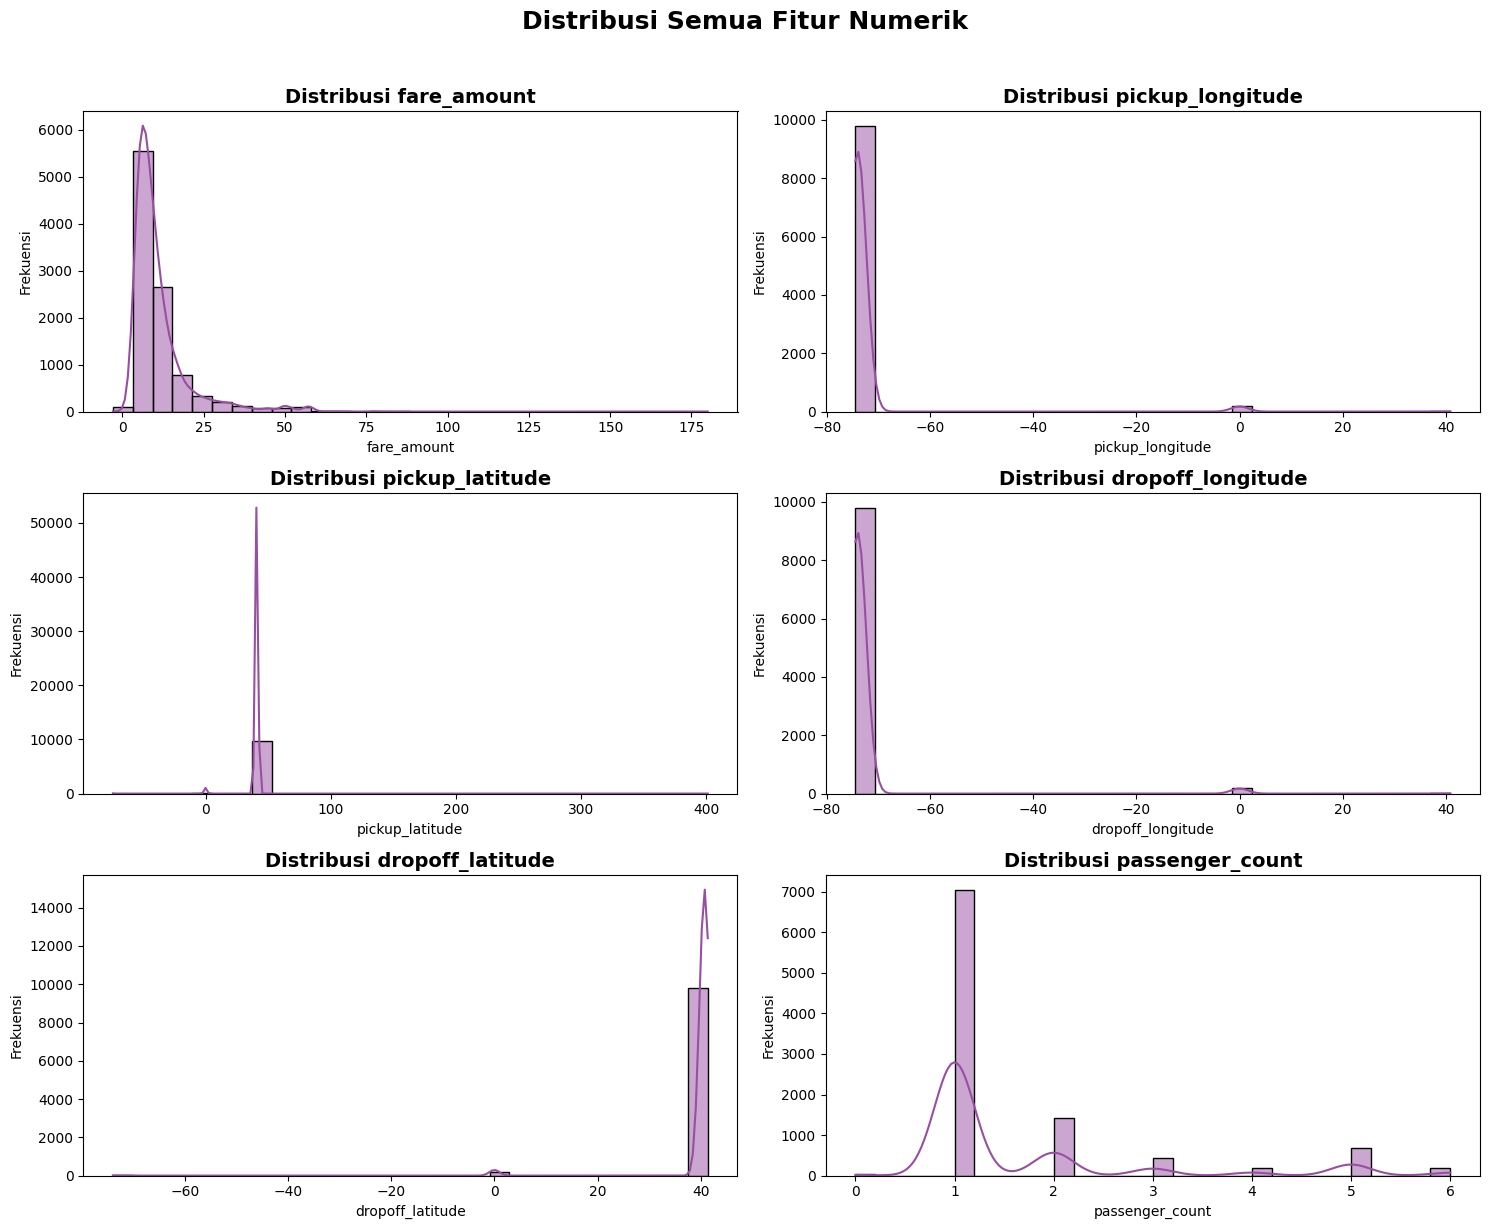

In [ ]:
# ===========================================================================================================================
# ============================================== VISUALISASI DATA ===========================================================
# ===========================================================================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Karena PySpark tidak bisa langsung divisualisasikan, kita ambil sample 10.000 baris saja
pdf = df.limit(10000).toPandas()

# Warna utama sesuai tema (#984ea3)
main_color = "#984ea3"

# =======================
# Diagram Batang
# =======================
# Daftar fitur numerik yang ingin divisualisasikan
numeric_cols = [
    'fare_amount', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'passenger_count'
]

plt.figure(figsize=(15, 12))
plt.suptitle("Distribusi Semua Fitur Numerik", fontsize=18, weight="bold", y=1.02)

# Loop setiap kolom dan plot histogram
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)  # menyesuaikan layout (3 baris, 2 kolom)
    sns.histplot(pdf[col], kde=True, color=main_color, bins=30)
    plt.title(f"Distribusi {col}", fontsize=14, weight="bold")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")

plt.tight_layout()
plt.show()

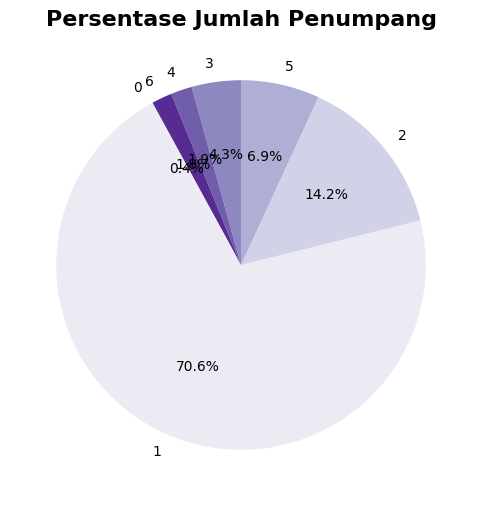

In [ ]:
# =======================
# 2️⃣ Pie Chart – Persentase Jumlah Penumpang
# =======================
plt.figure(figsize=(6,6))
pdf['passenger_count'].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=120, colors=sns.color_palette("Purples", n_colors=6))
plt.title("Persentase Jumlah Penumpang", fontsize=16, weight="bold")
plt.ylabel("")
plt.show()

## 🧍‍♀️ Persentase Jumlah Penumpang

Dari grafik di atas terlihat bahwa **mayoritas perjalanan taksi dilakukan oleh 1 penumpang**, yaitu sekitar **70.6%** dari total data.  
Sementara itu, perjalanan dengan **2 penumpang** menempati urutan kedua (14.2%), dan sisanya (3–6 penumpang) hanya sebagian kecil dari keseluruhan.  

Hal ini menunjukkan bahwa **perjalanan taksi di New York City umumnya bersifat individu**, bukan kelompok besar.

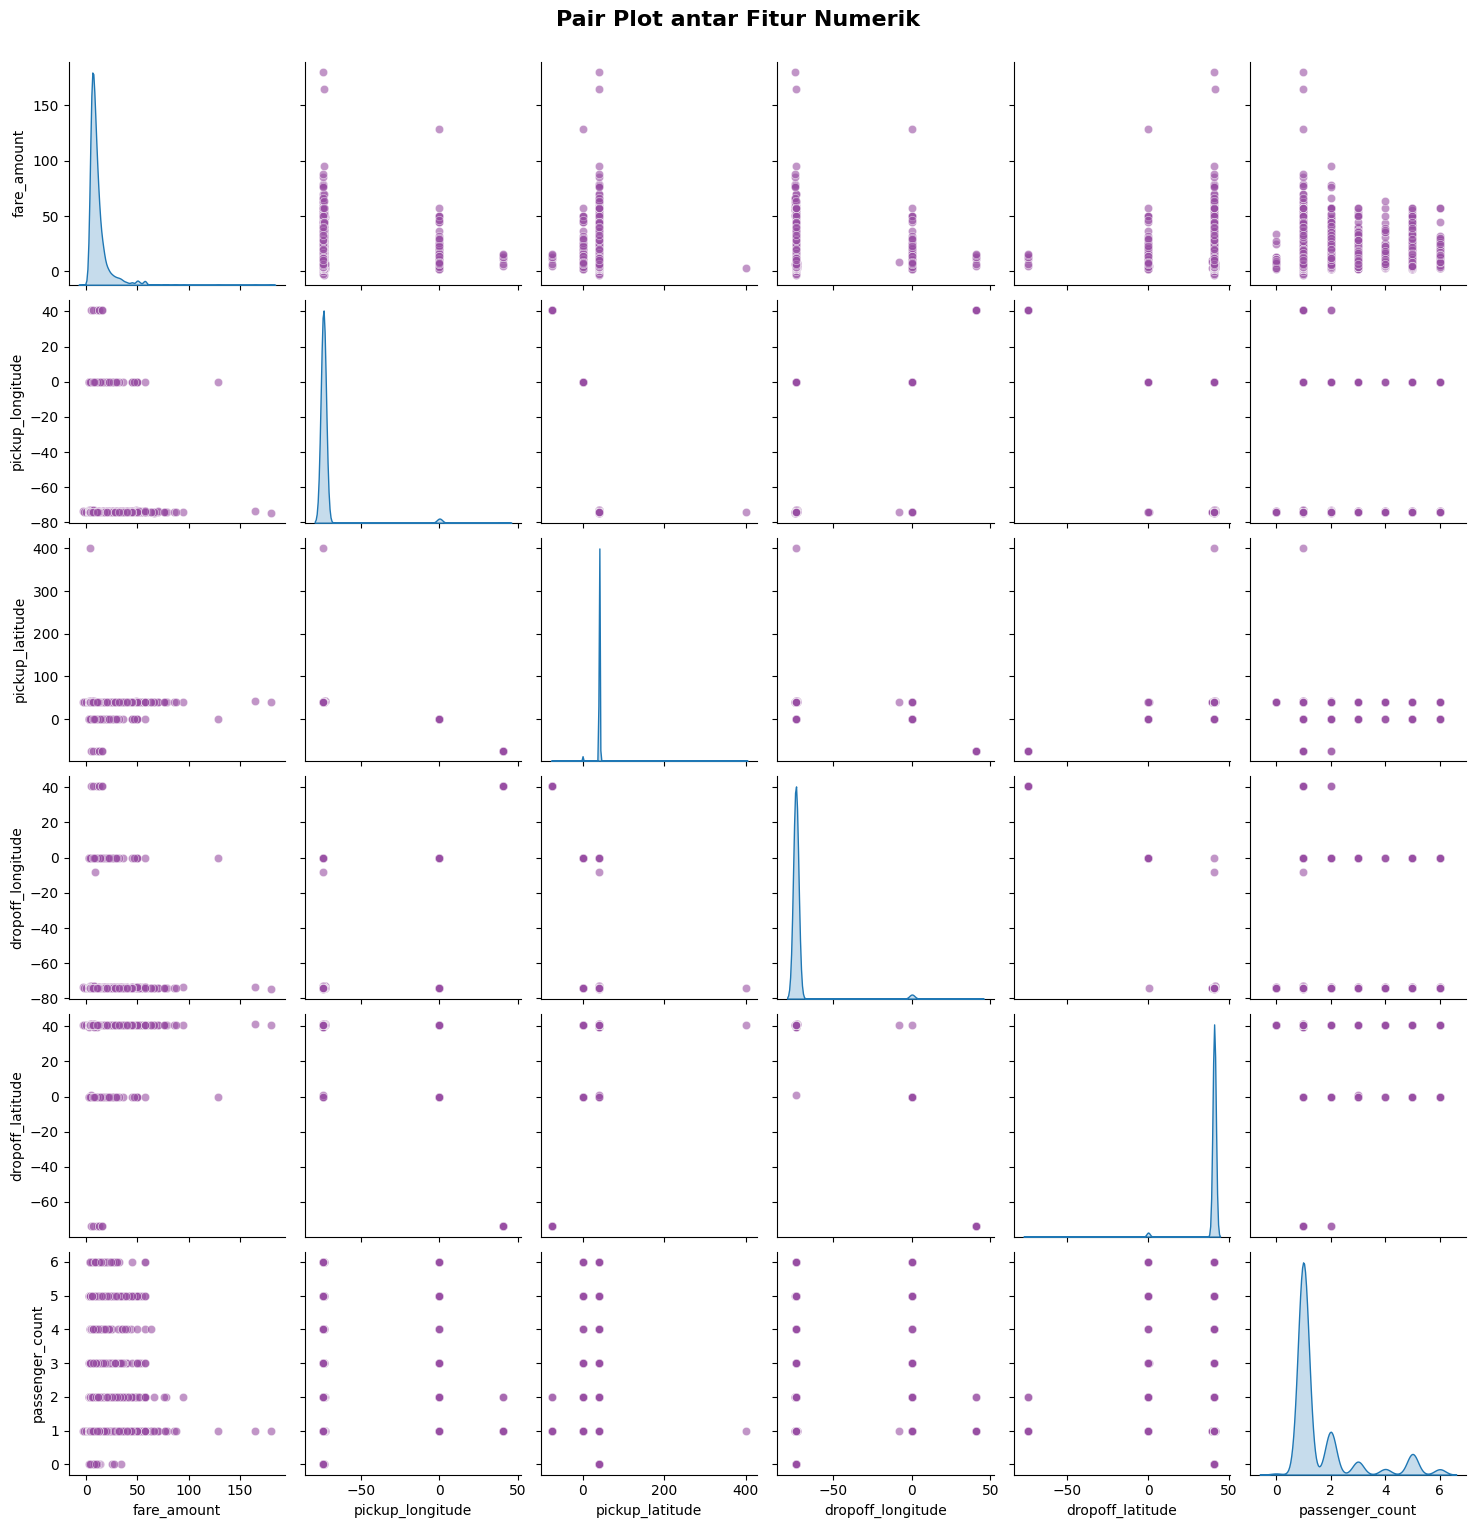

In [ ]:
# =======================
# 3️⃣ Pair Plot – Hubungan antar fitur numerik
# =======================
sns.pairplot(
    pdf[['fare_amount', 'pickup_longitude', 'pickup_latitude',
         'dropoff_longitude', 'dropoff_latitude', 'passenger_count']],
    diag_kind='kde', plot_kws={'alpha':0.6, 'color':main_color}
)
plt.suptitle("Pair Plot antar Fitur Numerik", fontsize=16, weight="bold", y=1.02)
plt.show()

## 📊 Pair Plot antar Fitur Numerik

Visualisasi di atas menunjukkan hubungan antara beberapa fitur numerik pada dataset.

- Sebaran **fare_amount** tampak condong ke kiri (positively skewed), menandakan sebagian besar tarif berada di kisaran rendah.  
- Tidak terlihat hubungan yang kuat antara **fare_amount** dengan **passenger_count**, artinya jumlah penumpang tidak terlalu memengaruhi tarif.  
- Sebaran koordinat (**pickup** dan **dropoff**) cukup tersebar luas, menunjukkan data berasal dari berbagai area di New York.  
- Terlihat adanya beberapa titik ekstrem (outlier) pada nilai koordinat dan tarif, yang mungkin perlu dibersihkan sebelum modeling.  

Secara umum, pair plot ini membantu mengidentifikasi pola, korelasi, dan outlier pada data numerik.

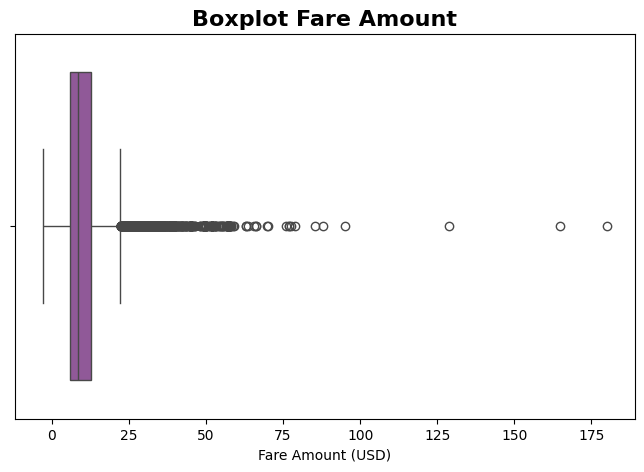

In [ ]:
# =======================
# 4️⃣ Boxplot – Deteksi Outlier
# =======================
plt.figure(figsize=(8,5))
sns.boxplot(x=pdf['fare_amount'], color=main_color)
plt.title("Boxplot Fare Amount", fontsize=16, weight="bold")
plt.xlabel("Fare Amount (USD)")
plt.show()

<hr style="border: 3px solid #7b1fa2;">

## 📦 **Visualisasi Boxplot Fare Amount**

Boxplot di atas menggambarkan **distribusi nilai tarif (fare amount)** dari dataset taksi yang digunakan.  
Visualisasi ini membantu untuk **mendeteksi adanya outlier (nilai ekstrem)** pada kolom `fare_amount`.

### 🔍 **Penjelasan:**
- Mayoritas nilai **fare amount** berada pada rentang **0 hingga sekitar 25 USD**.  
- Terlihat banyak **titik outlier** (lingkaran kecil) yang tersebar di sisi kanan grafik — ini menunjukkan adanya **penumpang yang membayar jauh lebih mahal** dibandingkan nilai rata-rata.  
- **Kotak ungu** (box) merepresentasikan *interquartile range (IQR)* atau 50% data utama, sedangkan **garis hitam di tengah box** menunjukkan *median* dari tarif perjalanan.  
- Outlier yang jauh dari box menandakan kemungkinan adanya:
  - Kesalahan input data (misalnya angka yang terlalu tinggi),
  - Atau memang kasus tarif yang tidak biasa (misalnya perjalanan sangat jauh).

### 💡 **Kesimpulan:**
Boxplot ini menunjukkan bahwa meskipun sebagian besar tarif berada pada kisaran rendah, terdapat sejumlah kecil perjalanan dengan tarif yang sangat tinggi yang perlu dianalisis lebih lanjut untuk memastikan kevalidan data.

<hr style="border: 3px solid #7b1fa2;">

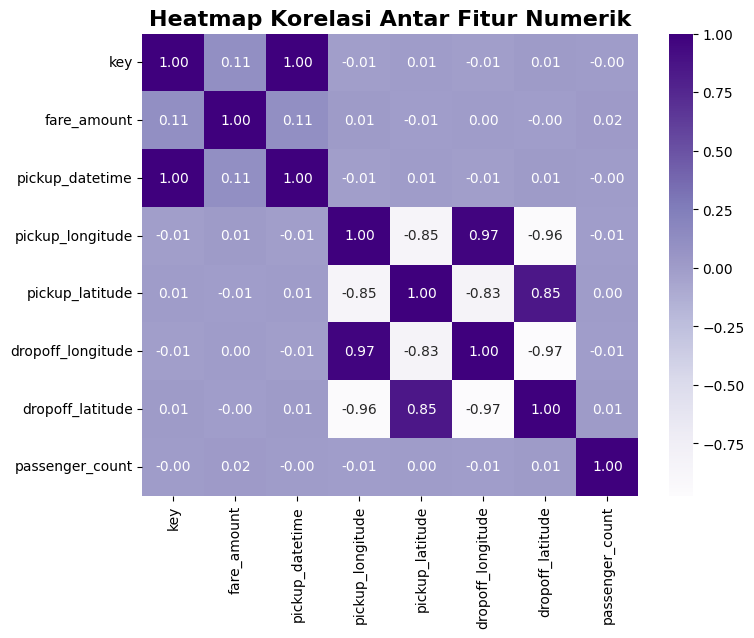

In [ ]:
# =======================
# 5️⃣ Heatmap – Korelasi Antar Fitur
# =======================
plt.figure(figsize=(8,6))
sns.heatmap(pdf.corr(), annot=True, cmap="Purples", fmt=".2f")
plt.title("Heatmap Korelasi Antar Fitur Numerik", fontsize=16, weight="bold")
plt.show()

<hr style="border: 3px solid #6a1b9a;">

## 💜 **Heatmap Korelasi Antar Fitur Numerik**

Visualisasi di atas menampilkan **hubungan korelasi antar fitur numerik** pada dataset taksi.  
Setiap sel pada heatmap menunjukkan **nilai korelasi (r)** antara dua variabel dengan rentang antara **-1 hingga +1**.

### 🔍 **Penjelasan:**
- Warna **ungu pekat (mendekati 1.00)** menunjukkan **hubungan positif yang kuat**, artinya jika satu variabel meningkat, variabel lainnya cenderung ikut meningkat.  
- Warna **ungu muda atau putih (mendekati 0)** menunjukkan **korelasi lemah atau hampir tidak ada hubungan** antara dua variabel.  
- Warna dengan nilai **negatif (mendekati -1)** menunjukkan **hubungan berlawanan arah** — jika satu variabel naik, variabel lainnya turun.

### 📈 **Interpretasi Utama:**
- **`pickup_longitude` dan `dropoff_longitude`** memiliki korelasi sangat tinggi (**r ≈ 0.97**), artinya lokasi awal dan akhir perjalanan cenderung berada pada garis bujur yang hampir sama.  
- **`pickup_latitude` dan `dropoff_latitude`** juga berkorelasi kuat (**r ≈ 0.85**), menunjukkan lokasi lintang yang berdekatan.  
- Nilai korelasi negatif yang kuat seperti antara **`pickup_longitude` dan `dropoff_latitude` (-0.96)** mengindikasikan hubungan berlawanan arah antara koordinat lintang dan bujur.  
- **`fare_amount`** (tarif) memiliki korelasi yang **lemah** terhadap semua fitur lain (sekitar **0.1** atau lebih rendah), menandakan bahwa tarif tidak bergantung langsung pada satu fitur numerik saja — kemungkinan dipengaruhi kombinasi beberapa variabel seperti jarak, waktu, dan lokasi.  
- **`passenger_count`** hampir tidak memiliki korelasi dengan fitur lain, menunjukkan bahwa jumlah penumpang tidak berpengaruh signifikan terhadap lokasi atau tarif.

### 💡 **Kesimpulan:**
Heatmap ini membantu mengidentifikasi fitur-fitur yang **berhubungan erat (multikolinearitas)** seperti longitude dan latitude, yang sebaiknya diolah dengan hati-hati saat membangun model machine learning untuk menghindari redundansi informasi.

<hr style="border: 3px solid #6a1b9a;">

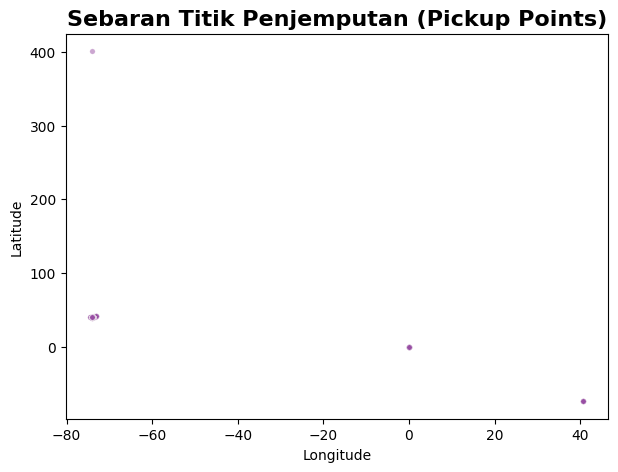

In [ ]:
# =======================
# 6️⃣ Scatter Plot – Hubungan Latitude vs Longitude
# =======================
plt.figure(figsize=(7,5))
sns.scatterplot(x='pickup_longitude', y='pickup_latitude', data=pdf,
                s=15, alpha=0.5, color=main_color)
plt.title("Sebaran Titik Penjemputan (Pickup Points)", fontsize=16, weight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

<hr style="border: 3px solid #8e24aa;">

## 🗺️ **Sebaran Titik Penjemputan (Pickup Points)**

Scatter plot di atas menunjukkan **sebaran lokasi penjemputan penumpang (pickup points)** berdasarkan koordinat **longitude** dan **latitude**.

### 🔍 **Penjelasan:**
- Setiap titik pada grafik mewakili **satu lokasi penjemputan** dalam dataset.  
- Sumbu **X (Longitude)** dan **Y (Latitude)** menggambarkan posisi geografis dari titik tersebut.  
- Warna ungu dengan ukuran titik kecil digunakan agar pola penyebaran terlihat lebih jelas tanpa tumpang tindih.  
- Terlihat bahwa sebagian besar titik berada di sekitar **longitude antara -80 hingga -70** dan **latitude antara 30 hingga 50**, yang kemungkinan besar merepresentasikan wilayah **New York City** — area utama dataset taksi ini.  
- Namun, terdapat juga **beberapa titik ekstrem** (longitude dan latitude yang sangat jauh dari area utama), menandakan adanya **data anomali atau kesalahan koordinat (outlier)** yang perlu dibersihkan sebelum analisis lebih lanjut.

### 💡 **Kesimpulan:**
Sebagian besar data penjemputan terkonsentrasi di area geografis tertentu (kemungkinan NYC), namun adanya beberapa titik jauh di luar area tersebut mengindikasikan perlunya **data cleaning** untuk menghapus koordinat yang tidak realistis.

<hr style="border: 3px solid #8e24aa;">

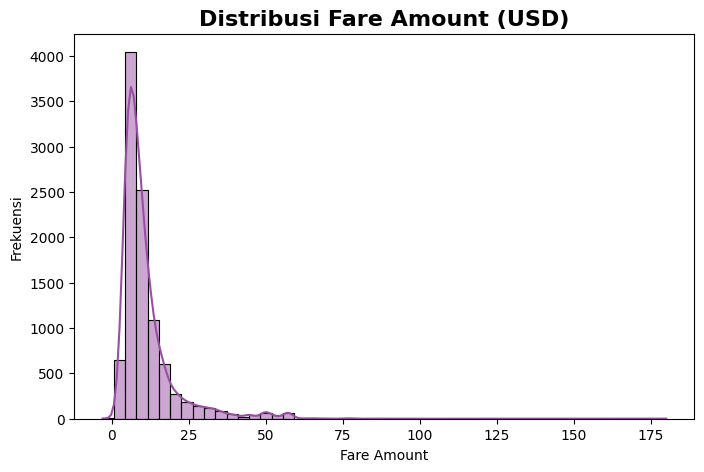

/tmp/ipython-input-3645759656.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='passenger_count', y='fare_amount', data=pdf, palette='Purples')


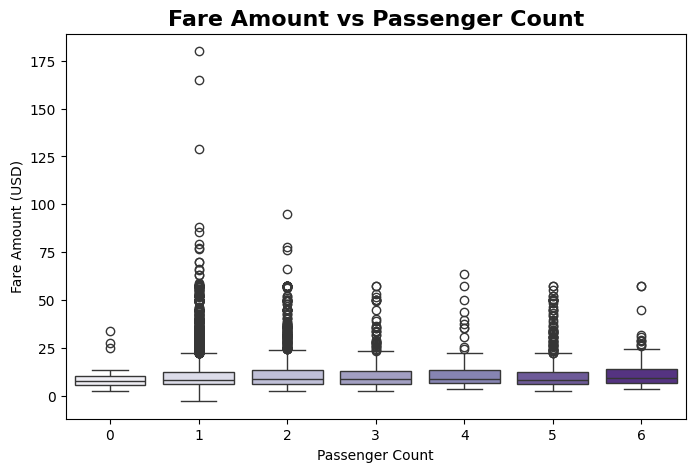

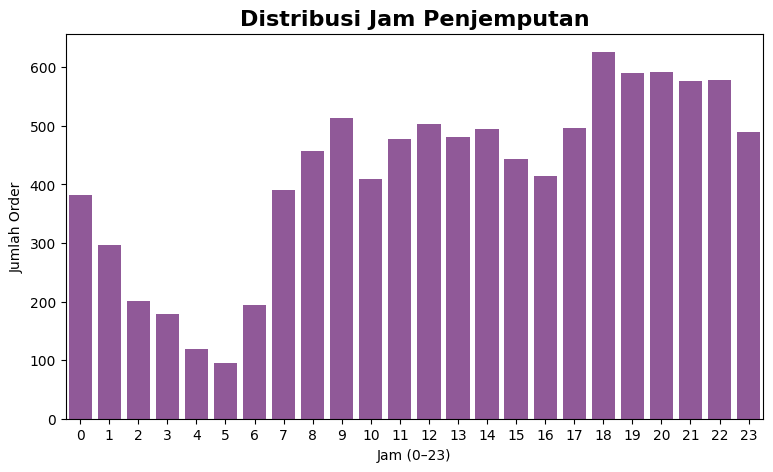

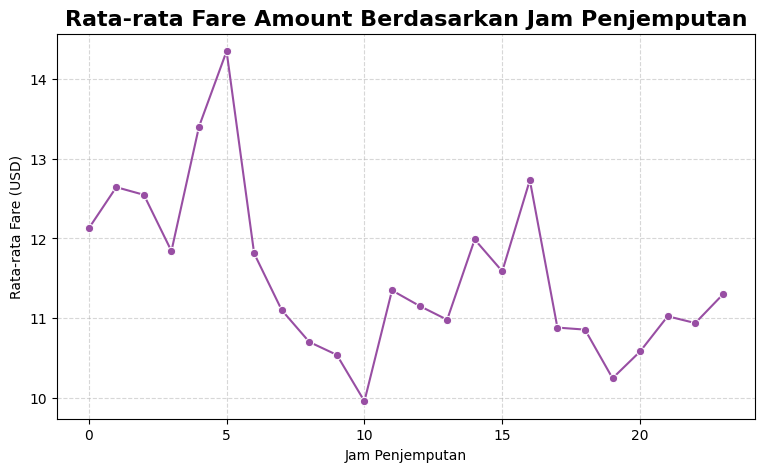

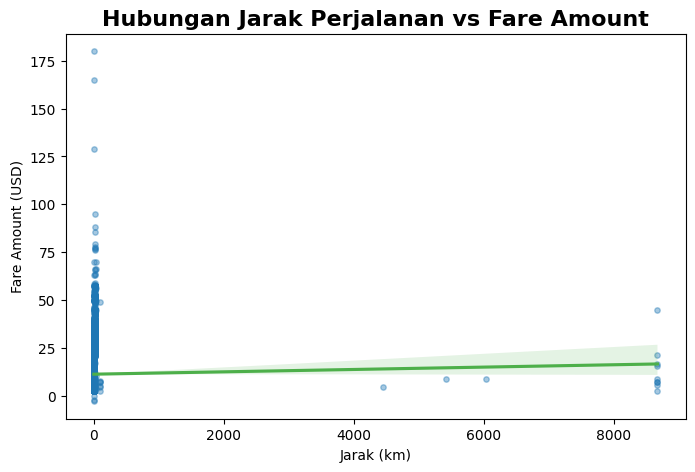

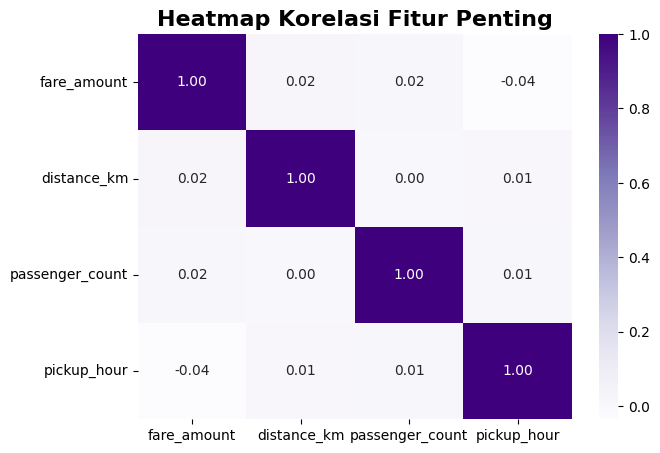

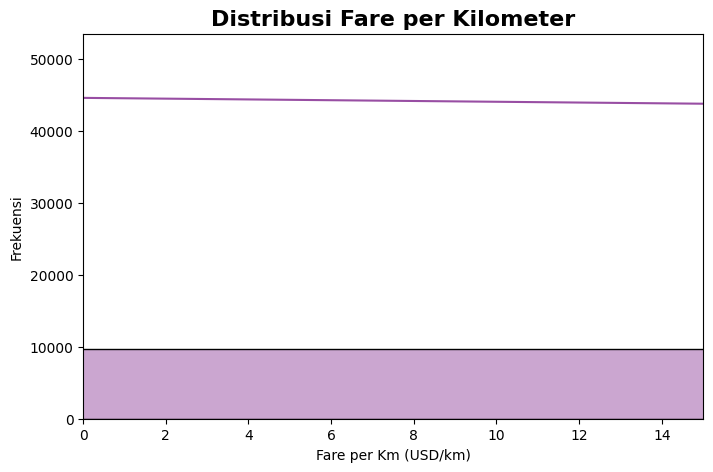

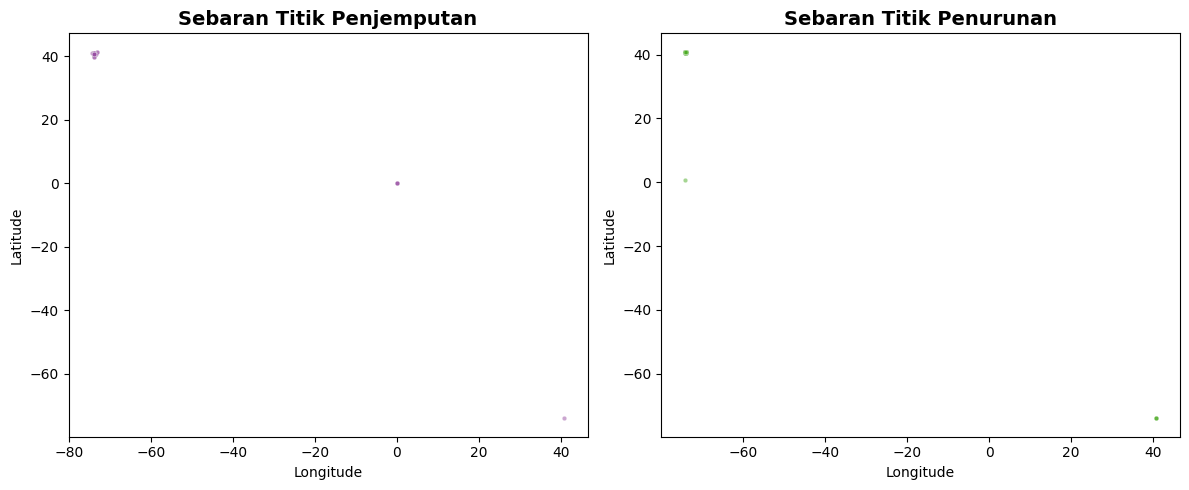


✅ Visualisasi lanjutan selesai! Sekarang kamu punya gambaran lengkap soal perilaku data NYC Taxi 🚕💜


In [ ]:
# ===========================================================================================================================
# ======================================= LANJUTAN VISUALISASI DATA =========================================================
# ===========================================================================================================================

import numpy as np

# =======================
# 7️⃣ Histogram – Distribusi Fare Amount
# =======================
plt.figure(figsize=(8,5))
sns.histplot(pdf['fare_amount'], bins=50, kde=True, color=main_color)
plt.title("Distribusi Fare Amount (USD)", fontsize=16, weight='bold')
plt.xlabel("Fare Amount")
plt.ylabel("Frekuensi")
plt.show()

# =======================
# 8️⃣ Boxplot – Fare Amount Berdasarkan Jumlah Penumpang
# =======================
plt.figure(figsize=(8,5))
sns.boxplot(x='passenger_count', y='fare_amount', data=pdf, palette='Purples')
plt.title("Fare Amount vs Passenger Count", fontsize=16, weight='bold')
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount (USD)")
plt.show()

# =======================
# 9️⃣ Distribusi Waktu Penjemputan (Jam)
# =======================
# Konversi kolom pickup_datetime menjadi format datetime
pdf['pickup_datetime'] = pd.to_datetime(pdf['pickup_datetime'], errors='coerce')
pdf['pickup_hour'] = pdf['pickup_datetime'].dt.hour

plt.figure(figsize=(9,5))
sns.countplot(x='pickup_hour', data=pdf, color=main_color)
plt.title("Distribusi Jam Penjemputan", fontsize=16, weight='bold')
plt.xlabel("Jam (0–23)")
plt.ylabel("Jumlah Order")
plt.show()

# =======================
# 🔟 Rata-rata Fare per Jam
# =======================
hourly_avg = pdf.groupby('pickup_hour')['fare_amount'].mean().reset_index()

plt.figure(figsize=(9,5))
sns.lineplot(x='pickup_hour', y='fare_amount', data=hourly_avg, marker='o', color=main_color)
plt.title("Rata-rata Fare Amount Berdasarkan Jam Penjemputan", fontsize=16, weight='bold')
plt.xlabel("Jam Penjemputan")
plt.ylabel("Rata-rata Fare (USD)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# =======================
# 11️⃣ Korelasi Fare Amount dengan Jarak (Haversine Distance)
# =======================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radius bumi (km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

pdf['distance_km'] = haversine(
    pdf['pickup_latitude'], pdf['pickup_longitude'],
    pdf['dropoff_latitude'], pdf['dropoff_longitude']
)

plt.figure(figsize=(8,5))
sns.regplot(x='distance_km', y='fare_amount', data=pdf,
            scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'#4daf4a'})
plt.title("Hubungan Jarak Perjalanan vs Fare Amount", fontsize=16, weight='bold')
plt.xlabel("Jarak (km)")
plt.ylabel("Fare Amount (USD)")
plt.show()

# =======================
# 12️⃣ Heatmap Korelasi Lengkap
# =======================
corr_cols = ['fare_amount', 'distance_km', 'passenger_count', 'pickup_hour']
plt.figure(figsize=(7,5))
sns.heatmap(pdf[corr_cols].corr(), annot=True, cmap='Purples', fmt='.2f')
plt.title("Heatmap Korelasi Fitur Penting", fontsize=16, weight='bold')
plt.show()

# =======================
# 13️⃣ Fare per Kilometer
# =======================
pdf['fare_per_km'] = pdf['fare_amount'] / pdf['distance_km']
pdf = pdf.replace([np.inf, -np.inf], np.nan).dropna(subset=['fare_per_km'])

plt.figure(figsize=(8,5))
sns.histplot(pdf['fare_per_km'], bins=40, color=main_color, kde=True)
plt.title("Distribusi Fare per Kilometer", fontsize=16, weight='bold')
plt.xlabel("Fare per Km (USD/km)")
plt.ylabel("Frekuensi")
plt.xlim(0, 15)
plt.show()

# =======================
# 14️⃣ Sebaran Pickup dan Dropoff (2 Peta Samping)
# =======================
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(x='pickup_longitude', y='pickup_latitude', data=pdf.sample(3000),
                s=10, alpha=0.5, color=main_color, ax=ax[0])
ax[0].set_title("Sebaran Titik Penjemputan", fontsize=14, weight='bold')
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")

sns.scatterplot(x='dropoff_longitude', y='dropoff_latitude', data=pdf.sample(3000),
                s=10, alpha=0.5, color="#4dac26", ax=ax[1])
ax[1].set_title("Sebaran Titik Penurunan", fontsize=14, weight='bold')
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

print("\n✅ Visualisasi lanjutan selesai! Sekarang kamu punya gambaran lengkap soal perilaku data NYC Taxi 🚕💜")

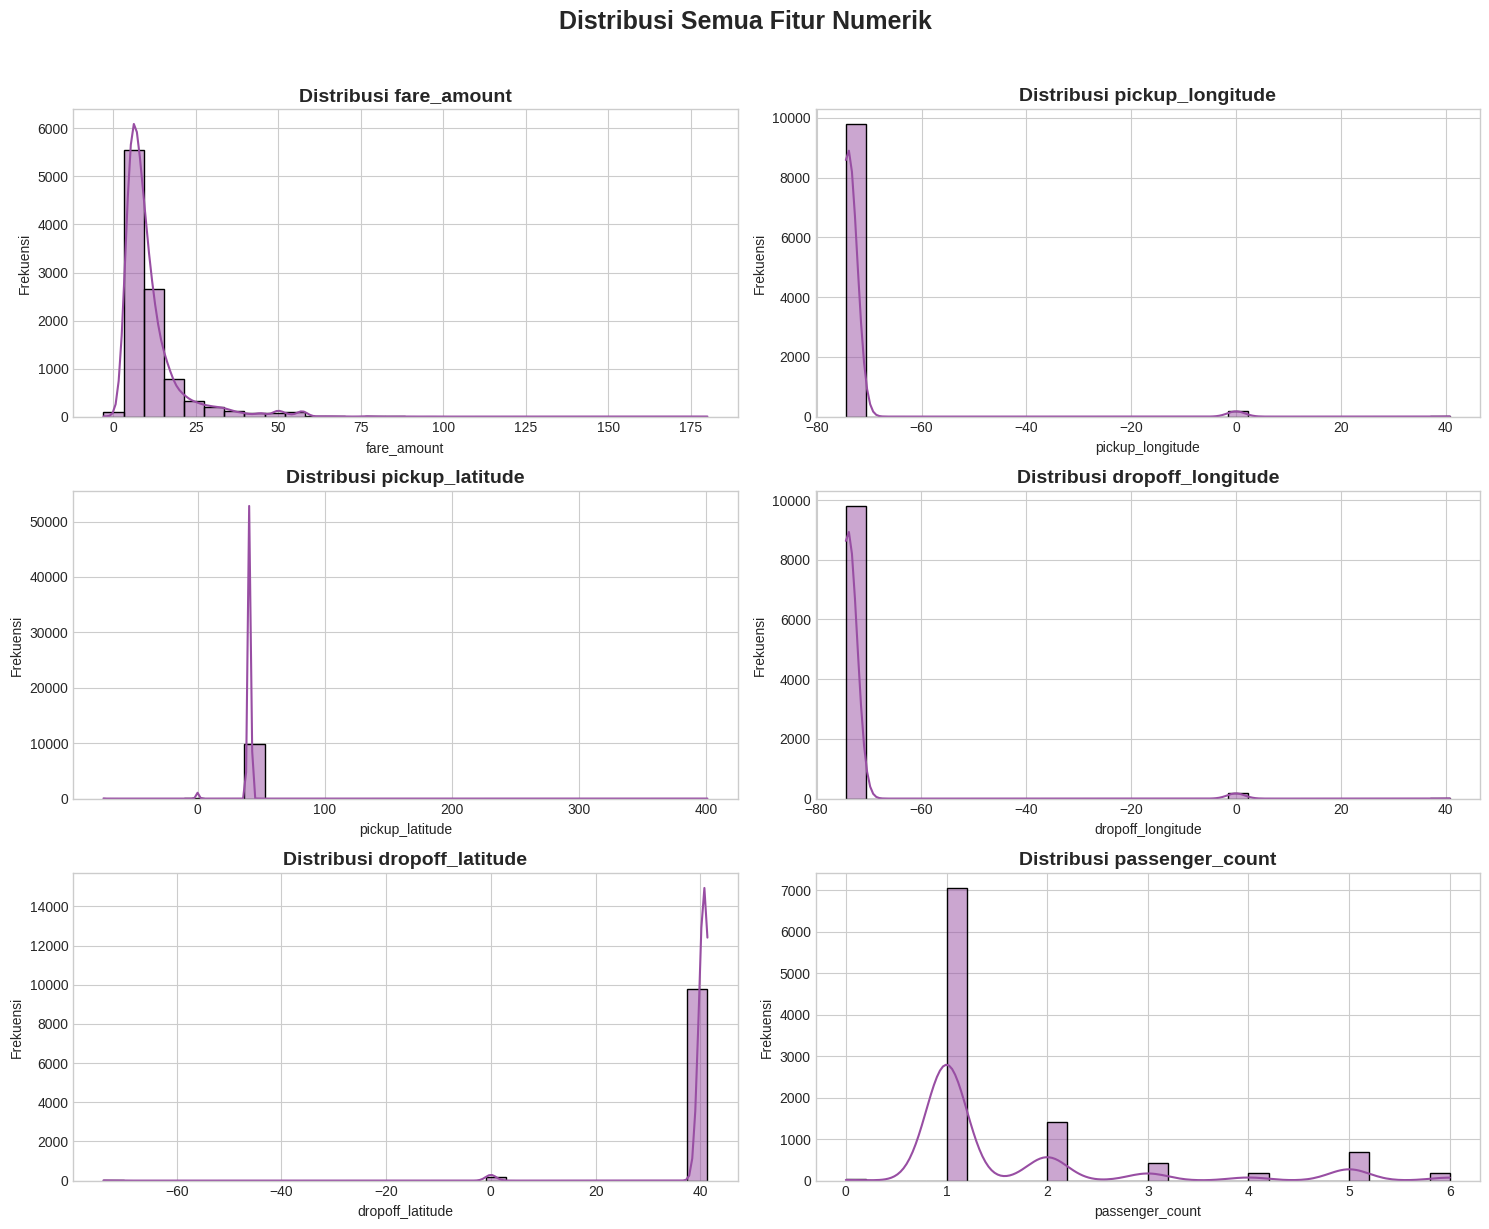

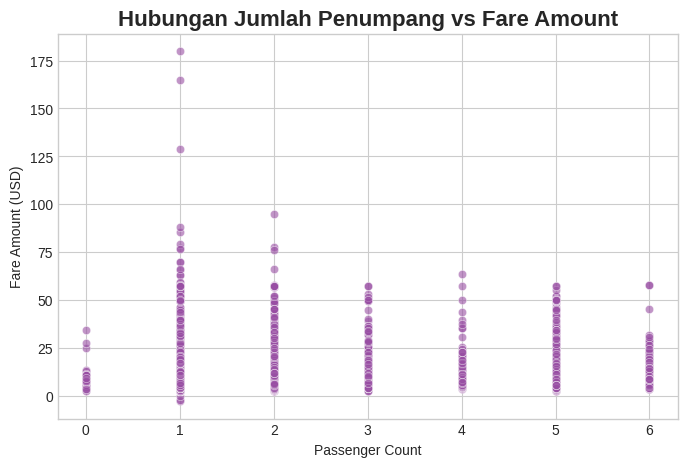

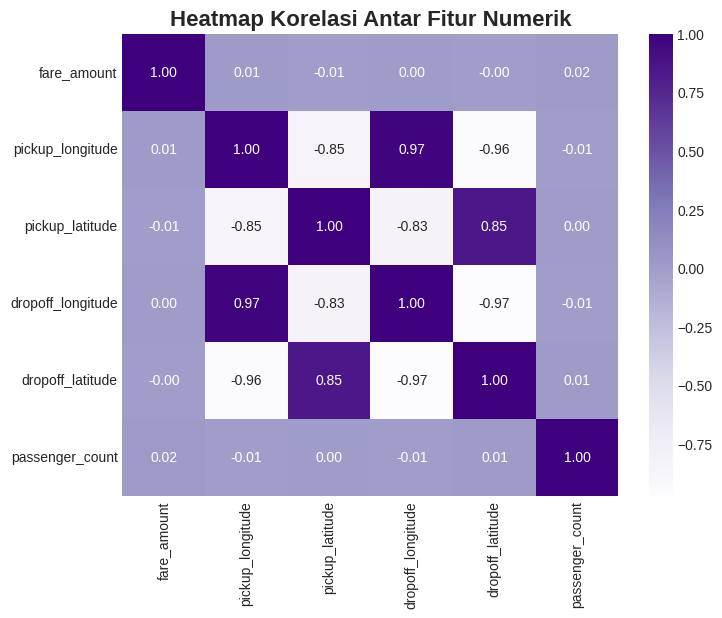

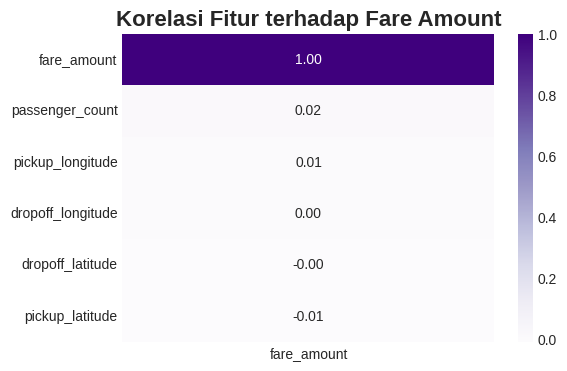

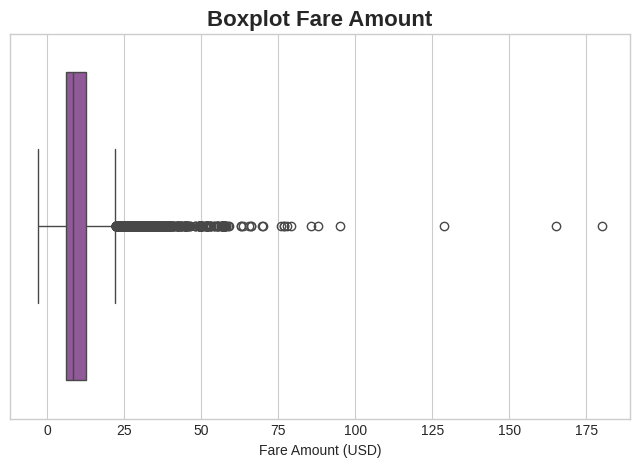

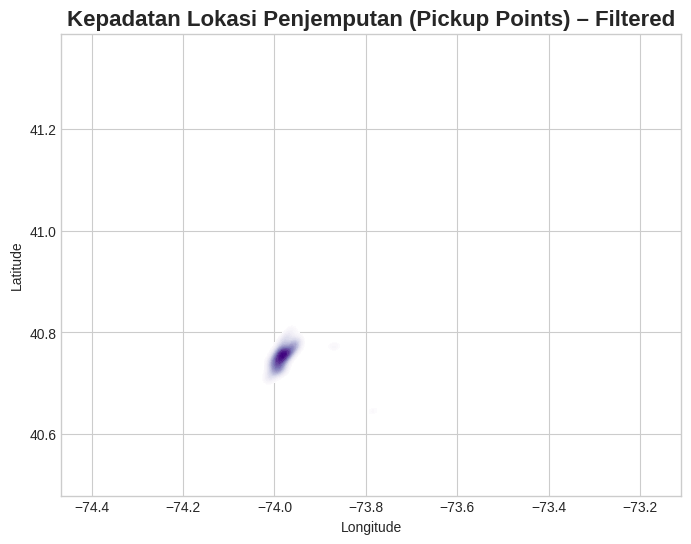

/tmp/ipython-input-1744527141.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


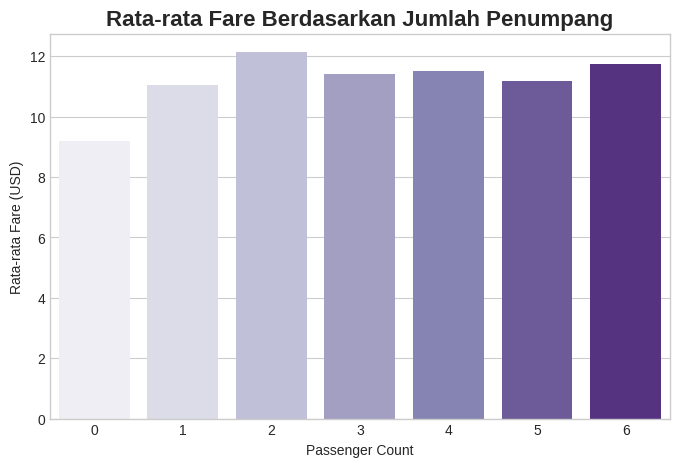

In [ ]:
# =====================================================================
# 🎨 VISUALISASI DATA TAKSI NYC (PySpark → Pandas)
# =====================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

# Karena PySpark tidak bisa langsung divisualisasikan, ambil sample
pdf = df.limit(10000).toPandas()

# Warna utama
main_color = "#984ea3"

# =====================================================================
# 1️⃣ DISTRIBUSI SEMUA FITUR NUMERIK
# =====================================================================
numeric_cols = [
    'fare_amount', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'passenger_count'
]

plt.figure(figsize=(15, 12))
plt.suptitle("Distribusi Semua Fitur Numerik", fontsize=18, weight="bold", y=1.02)

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(pdf[col], kde=True, color=main_color, bins=30)
    plt.title(f"Distribusi {col}", fontsize=14, weight="bold")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")

plt.tight_layout()
plt.show()

# =====================================================================
# 2️⃣ SCATTER PLOT – Passenger Count vs Fare Amount
# =====================================================================
plt.figure(figsize=(8,5))
sns.scatterplot(x='passenger_count', y='fare_amount', data=pdf, alpha=0.6, color=main_color)
plt.title("Hubungan Jumlah Penumpang vs Fare Amount", fontsize=16, weight="bold")
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount (USD)")
plt.show()

# =====================================================================
# 3️⃣ HEATMAP KORELASI ANTAR FITUR NUMERIK
# =====================================================================
plt.figure(figsize=(8,6))
corr_matrix = pdf.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="Purples", fmt=".2f")
plt.title("Heatmap Korelasi Antar Fitur Numerik", fontsize=16, weight="bold")
plt.show()

# =====================================================================
# 4️⃣ HEATMAP FOKUS – Korelasi terhadap Fare Amount
# =====================================================================
plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix[['fare_amount']].sort_values(by='fare_amount', ascending=False),
    annot=True, cmap="Purples", fmt=".2f"
)
plt.title("Korelasi Fitur terhadap Fare Amount", fontsize=16, weight="bold")
plt.show()

# =====================================================================
# 5️⃣ BOX PLOT – Deteksi Outlier Fare Amount
# =====================================================================
plt.figure(figsize=(8,5))
sns.boxplot(x=pdf['fare_amount'], color=main_color)
plt.title("Boxplot Fare Amount", fontsize=16, weight="bold")
plt.xlabel("Fare Amount (USD)")
plt.show()

# =====================================================================
# 6️⃣ DENSITY PLOT – Sebaran Lokasi Penjemputan (Pickup Points)
# =====================================================================
# Filter agar hanya area NYC (menghindari error "Contour levels must be increasing")
pdf_filtered = pdf[
    (pdf['pickup_longitude'] > -75) & (pdf['pickup_longitude'] < -72) &
    (pdf['pickup_latitude'] > 40) & (pdf['pickup_latitude'] < 42)
]

plt.figure(figsize=(8,6))
sns.kdeplot(
    data=pdf_filtered,
    x='pickup_longitude', y='pickup_latitude',
    fill=True, levels=50, thresh=0.1, cmap="Purples"
)
plt.title("Kepadatan Lokasi Penjemputan (Pickup Points) – Filtered", fontsize=16, weight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# =====================================================================
# 7️⃣ BAR PLOT – Rata-rata Fare per Jumlah Penumpang
# =====================================================================
plt.figure(figsize=(8,5))
sns.barplot(
    x='passenger_count', y='fare_amount', data=pdf,
    estimator='mean', errorbar=None, palette="Purples"
)
plt.title("Rata-rata Fare Berdasarkan Jumlah Penumpang", fontsize=16, weight="bold")
plt.xlabel("Passenger Count")
plt.ylabel("Rata-rata Fare (USD)")
plt.show()

# **CLEANING DATA**

In [ ]:
# ===========================================================================================================================
# ============================================== CLEANING DATA ==============================================================
# ===========================================================================================================================

print("\n============================== CLEANING DATA ==============================")

# 1️⃣ Hapus data dengan nilai negatif pada fare_amount
df_clean = df.filter(F.col("fare_amount") >= 0)

# 2️⃣ Hapus data dengan passenger_count tidak logis (0 atau lebih dari 6)
df_clean = df_clean.filter((F.col("passenger_count") > 0) & (F.col("passenger_count") <= 6))

# 3️⃣ Hapus data dengan koordinat pickup/dropoff di luar area NYC
# Kode ini digunakan untuk membersihkan data lokasi taksi (pickup dan dropoff) yang berada di luar wilayah New York City (NYC).
df_clean = df_clean.filter(
    (F.col("pickup_longitude") >= -75) & (F.col("pickup_longitude") <= -72) &
    (F.col("pickup_latitude") >= 40) & (F.col("pickup_latitude") <= 42) &
    (F.col("dropoff_longitude") >= -75) & (F.col("dropoff_longitude") <= -72) &
    (F.col("dropoff_latitude") >= 40) & (F.col("dropoff_latitude") <= 42)
)

# 4️⃣ Cek kembali jumlah baris setelah pembersihan
print("\nJumlah baris sebelum cleaning:", num_rows)
print("Jumlah baris sesudah cleaning:", df_clean.count())


============================== CLEANING DATA ==============================

Jumlah baris sebelum cleaning: 55423856
Jumlah baris sesudah cleaning: 54064188


In [ ]:
# ===========================================================================================================================
# 1️⃣ CEK DAN HAPUS MISSING VALUE
# ===========================================================================================================================
print("🔹 Jumlah missing value per kolom:")
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()

# Hapus baris dengan missing value
df = df.na.drop()
print(f"\nJumlah data setelah drop missing value: {df.count()}")

🔹 Jumlah missing value per kolom:
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|key|fare_amount|pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|  0|          0|              0|               0|              0|              376|             376|              0|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+


Jumlah data setelah drop missing value: 55423480


In [ ]:
# ===========================================================================================================================
# 2️⃣ HAPUS DUPLIKAT DATA
# ===========================================================================================================================
before = df.count()
df = df.dropDuplicates()
after = df.count()

print(f"\nJumlah data sebelum hapus duplikat: {before}")
print(f"Jumlah data sesudah hapus duplikat: {after}")
print(f"Jumlah duplikat dihapus: {before - after}")


Jumlah data sebelum hapus duplikat: 55423480
Jumlah data sesudah hapus duplikat: 55421830
Jumlah duplikat dihapus: 1650


In [ ]:
# ===========================================================================================================================
# 4️⃣ PENANGANAN OUTLIER MENGGUNAKAN METODE IQR
# ===========================================================================================================================
def remove_outliers_iqr(df: DataFrame, column: str) -> DataFrame:
    quantiles = df.approxQuantile(column, [0.25, 0.75], 0.05)
    Q1, Q3 = quantiles
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df.count()
    df = df.filter((F.col(column) >= lower) & (F.col(column) <= upper))
    after = df.count()
    print(f"Kolom {column}: Hapus {before - after} outlier")
    return df

print("\n🚫 Menghapus outlier dengan metode IQR...")
for col in ["fare_amount"]:
    df = remove_outliers_iqr(df, col)

print(f"\nJumlah data akhir setelah outlier cleaning: {df.count()}")


🚫 Menghapus outlier dengan metode IQR...
Kolom fare_amount: Hapus 4617830 outlier

Jumlah data akhir setelah outlier cleaning: 50804000


# **Preprocessing Data**

In [ ]:
from pyspark.sql import functions as F

# Asumsikan data Anda ada di 'df_clean'
# A. Ekstraksi Fitur Waktu
#    (Saya asumsikan Anda punya kolom 'pickup_datetime')
df_feat = df_clean.withColumn('jam_penjemputan', F.hour('pickup_datetime')) \
                    .withColumn('hari_dalam_minggu', F.dayofweek('pickup_datetime')) \
                    .withColumn('bulan', F.month('pickup_datetime')) \
                    .withColumn('tahun', F.year('pickup_datetime'))

# B. Hitung Jarak Haversine (Cara PySpark)
R = 6371.0 # Radius bumi dalam KM

lat1_rad = F.radians(F.col('pickup_latitude'))
lon1_rad = F.radians(F.col('pickup_longitude'))
lat2_rad = F.radians(F.col('dropoff_latitude'))
lon2_rad = F.radians(F.col('dropoff_longitude'))

dlon = lon2_rad - lon1_rad
dlat = lat2_rad - lat1_rad

a = F.sin(dlat / 2)**2 + F.cos(lat1_rad) * F.cos(lat2_rad) * F.sin(dlon / 2)**2
c = 2 * F.atan2(F.sqrt(a), F.sqrt(1 - a))
jarak_km = R * c

df_feat = df_feat.withColumn('jarak_km', jarak_km)

# C. Pembersihan Lanjutan (Sangat Penting!)
#    Hapus data yang tidak masuk akal SETELAH menghitung jarak
df_feat = df_feat.filter((F.col('fare_amount') > 0) & (F.col('jarak_km') > 0.01))

print("DataFrame dengan Fitur Baru:")
df_feat.select('fare_amount', 'jarak_km', 'jam_penjemputan', 'hari_dalam_minggu').show(5)

DataFrame dengan Fitur Baru:
+-----------+------------------+---------------+-----------------+
|fare_amount|          jarak_km|jam_penjemputan|hari_dalam_minggu|
+-----------+------------------+---------------+-----------------+
|        4.5| 1.030763935049508|             17|                2|
|       16.9| 8.450133595806385|             16|                3|
|        5.7|1.3895252257697843|              0|                5|
|        7.7|  2.79927023998294|              4|                7|
|        5.3|1.9991567879963377|              7|                3|
+-----------+------------------+---------------+-----------------+
only showing top 5 rows



# **TRANSFORMASI DATA DAN IMPLEMENTASI MODEL**

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

# 1. Tentukan kolom kategorikal dan numerik (yang baru!)
categorical_cols = ['jam_penjemputan', 'hari_dalam_minggu', 'bulan']
numeric_cols = ['passenger_count', 'tahun', 'jarak_km']

# --- STAGES UNTUK PIPELINE ---

# 2. Stage A: Ubah Kategori (String/Angka) menjadi Indeks
#    Contoh: 'jam_7' -> 1.0, 'jam_8' -> 2.0
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_index", handleInvalid="keep")
    for c in categorical_cols
]

# 3. Stage B: One-Hot Encoding
#    Contoh: 1.0 -> [1, 0, 0], 2.0 -> [0, 1, 0]
encoder_input_cols = [f"{c}_index" for c in categorical_cols]
encoder_output_cols = [f"{c}_vec" for c in categorical_cols]
encoder = OneHotEncoder(
    inputCols=encoder_input_cols,
    outputCols=encoder_output_cols
)

# 4. Stage C: Gabungkan Fitur Numerik
numeric_assembler = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="numeric_features_vec"
)

# 5. Stage D: Standardisasi Fitur Numerik
scaler = StandardScaler(
    inputCol="numeric_features_vec",
    outputCol="numeric_features_scaled",
    withMean=True, withStd=True
)

# 6. Stage E: Gabungkan SEMUA Fitur (Kategorikal + Numerik)
final_feature_cols = encoder_output_cols + ['numeric_features_scaled']
final_assembler = VectorAssembler(
    inputCols=final_feature_cols,
    outputCol="features"  # Nama default yang disukai MLlib
)

# 7. Buat Pipeline-nya
pipeline = Pipeline(stages=indexers + [encoder, numeric_assembler, scaler, final_assembler])

# 8. Latih Pipeline pada data
#    (Pipeline 'fit' akan mempelajari data, 'transform' akan menerapkan)
pipeline_model = pipeline.fit(df_feat)
df_transformed = pipeline_model.transform(df_feat)

# 9. Bagi Data (Data Anda sekarang SIAP)
train_data, test_data = df_transformed.randomSplit([0.8, 0.2], seed=42)

print("Data siap untuk model:")
train_data.select('features', 'fare_amount').show(5, truncate=False)

Data siap untuk model:
+---------------------------------------------------------------------------------------------------+-----------+
|features                                                                                           |fare_amount|
+---------------------------------------------------------------------------------------------------+-----------+
|(46,[16,26,35,43,44,45],[1.0,1.0,1.0,-0.5291913117469997,-1.4700064564061313,0.45919439362491815]) |15.0       |
|(46,[16,26,35,43,44,45],[1.0,1.0,1.0,0.2357611791106663,-1.4700064564061313,-0.5535677086386245])  |5.8        |
|(46,[16,26,35,43,44,45],[1.0,1.0,1.0,-0.5291913117469997,-1.4700064564061313,-0.3755043583519244]) |7.4        |
|(46,[16,26,35,43,44,45],[1.0,1.0,1.0,-0.5291913117469997,-1.4700064564061313,-0.49587317207334963])|5.4        |
|(46,[16,26,35,43,44,45],[1.0,1.0,1.0,-0.5291913117469997,-1.4700064564061313,-0.2982871511581911]) |7.4        |
+----------------------------------------------------------------

In [ ]:
# Jalankan ini pada df_feat
print("=== Korelasi Baru (Setelah Feature Engineering) ===")

# Hitung, simpan ke variabel, lalu print
corr_jarak = df_feat.stat.corr("jarak_km", "fare_amount")
print(f"🔹 Korelasi jarak_km terhadap fare_amount: {corr_jarak}")

# Hitung, simpan ke variabel, lalu print
corr_penumpang = df_feat.stat.corr("passenger_count", "fare_amount")
print(f"🔹 Korelasi passenger_count terhadap fare_amount: {corr_penumpang}")

=== Korelasi Baru (Setelah Feature Engineering) ===
🔹 Korelasi jarak_km terhadap fare_amount: 0.3856166051479449
🔹 Korelasi passenger_count terhadap fare_amount: 0.006794102704176555


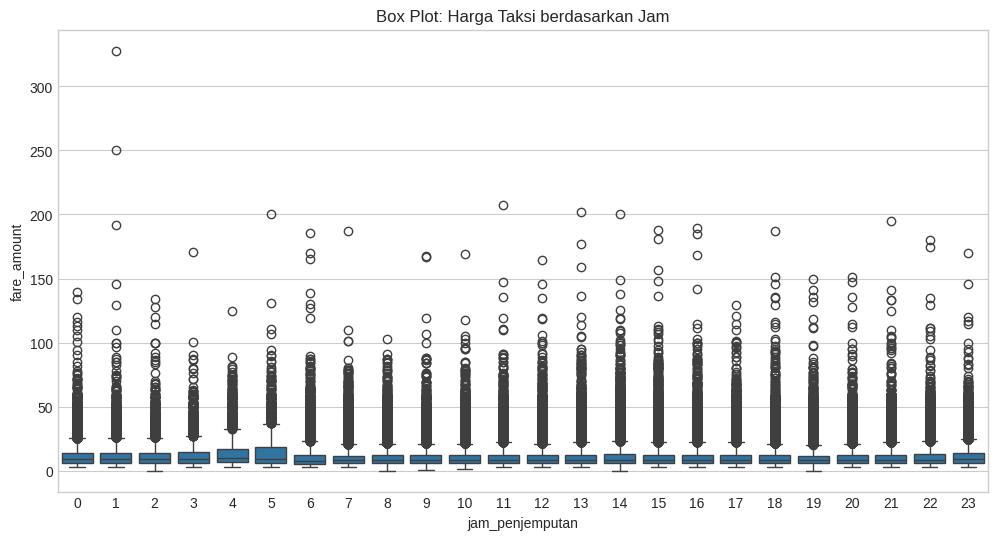

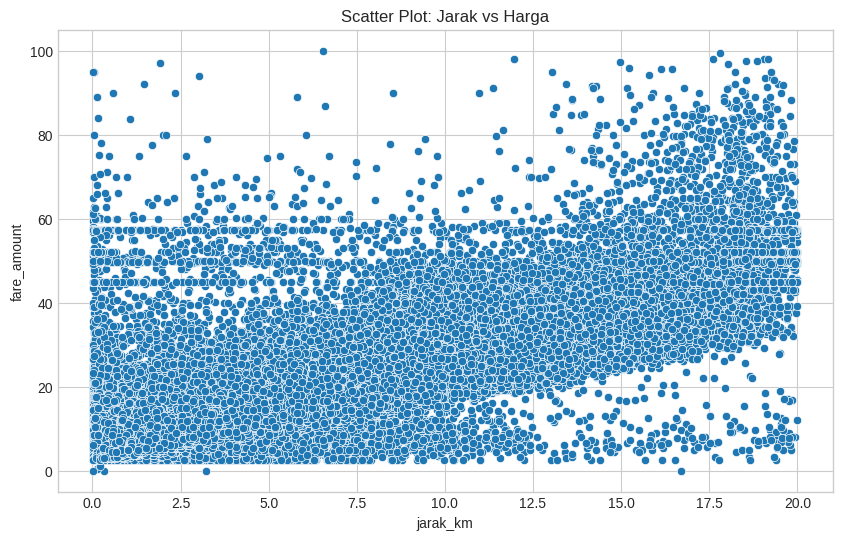

In [ ]:
# 1. Ambil sampel (1% dari data) dan konversi ke Pandas
df_sample = df_feat.sample(fraction=0.01, seed=42).toPandas() # Sesuaikan 'fraction'

# 2. Buat visualisasi (Contoh: Box Plot)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_sample, x='jam_penjemputan', y='fare_amount')
plt.title('Box Plot: Harga Taksi berdasarkan Jam')
plt.show()

# 3. Buat visualisasi (Contoh: Scatter Plot)
plt.figure(figsize=(10, 6))
# Batasi 'fare_amount' dan 'jarak_km' agar plot terlihat jelas
df_sample_filtered = df_sample[(df_sample['fare_amount'] < 100) & (df_sample['jarak_km'] < 20)]
sns.scatterplot(data=df_sample_filtered, x='jarak_km', y='fare_amount')
plt.title('Scatter Plot: Jarak vs Harga')
plt.show()

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Gunakan data 'train_data' dan 'test_data' dari hasil Pipeline
# Perhatikan: 'featuresCol' sekarang adalah "features" (output dari Pipeline)
lr = LinearRegression(featuresCol="features", labelCol="fare_amount")

# Latih model
lr_model = lr.fit(train_data)

# Prediksi pada data uji
predictions = lr_model.transform(test_data)

# Tampilkan beberapa hasil prediksi
predictions.select("fare_amount", "prediction", "jarak_km").show(10)

# Kode Evaluator Anda (RMSE, R2, dll.) sudah benar!
# Jalankan saja kode evaluasi Anda di sini.
evaluator_rmse = RegressionEvaluator(
    labelCol="fare_amount", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(
    labelCol="fare_amount", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print("\n📊 === Evaluasi Model Linear Regression (Setelah Perbaikan) ===")
print(f"🔹 RMSE: {rmse:.4f}")
print(f"🔹 R²: {r2:.4f}")

+-----------+------------------+------------------+
|fare_amount|        prediction|          jarak_km|
+-----------+------------------+------------------+
|       29.4|34.199216494393376|15.197689898147553|
|        5.0|3.4899936889268277|0.7415811437268904|
|       16.5|14.999067977587606| 6.202528574241228|
|        5.4| 4.509628541621328|1.2737813136375975|
|       11.3|11.259180952352704| 4.544205489065183|
|        9.0| 8.772708592114014| 3.349320539098726|
|        4.2| 3.663582660166947|0.9486593221779976|
|        6.6| 5.573393800894675| 1.819487263210194|
|       10.2|  9.50695955587225|3.7462029468852345|
|        9.7|6.8938613486452995| 2.491819412625983|
+-----------+------------------+------------------+
only showing top 10 rows


📊 === Evaluasi Model Linear Regression (Setelah Perbaikan) ===
🔹 RMSE: 34.7329
🔹 R²: 0.0521
